In [1]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import torch
from torch import nn, Tensor
import torch.nn.functional as F

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper
import time
import tqdm

In [2]:
# Construct the ground truth Gaussian Mixture Model (GMM) and sample from it

# 1. Define the mixture parameters
n_discrete_values = 2

# Weights for each Gaussian (must sum to 1)
weights = np.array([0.8, 0.2], dtype=np.float32)

# Means shape must be (n_components, n_features) -> (2, 1) for 1D
means = np.array([[-0.5], 
                  [1.0]], dtype=np.float32)

n_continuous_features = means.shape[-1]

# Variances shape for 'full' covariance must be (n_components, n_features, n_features) -> (2, 1, 1)
variances = np.array([[[8.0]], 
                      [[0.3]]], dtype=np.float32)

# 2. Instantiate the model without fitting
gmm = GaussianMixture(n_components=n_discrete_values, covariance_type='full')

# 3. Manually assign the standard attributes
gmm.weights_ = weights
gmm.means_ = means
gmm.covariances_ = variances

# 4. Compute and assign the precision Cholesky matrices
# This is a strict requirement for scikit-learn's .sample() method
gmm.precisions_cholesky_ = np.linalg.cholesky(np.linalg.inv(variances))

# 5. Generate samples
n_samples = 1000
X, component_labels = gmm.sample(n_samples=n_samples)


In [3]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)



In [4]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [5]:
# training arguments
lr = 0.001
batch_size = 32768
iterations = 50000
print_every = 2000 
hidden_dim = 128

# checkpoint arguments
ckpt_path = "/home/nagleam/PycharmProjects/cse515/mog4_checkpoint.pt"

# velocity field model init
vf = MLP(input_dim=(n_continuous_features + n_discrete_values), time_dim=1, hidden_dim=hidden_dim).to(device) 

# instantiate an affine path object
path = AffineProbPath(scheduler=CondOTScheduler())

# init optimizer
optim = torch.optim.Adam(vf.parameters(), lr=lr) 

# train
start_time = time.time()
for i in tqdm.tqdm(range(iterations)):
    optim.zero_grad() 

    # sample data
    continuous_samples, discrete_samples = gmm.sample(n_samples=batch_size)
    continuous_samples = torch.tensor(continuous_samples, dtype=torch.float32, device=device)
    discrete_samples = torch.tensor(discrete_samples, dtype=torch.long, device=device)
    one_hot_labels = F.one_hot(discrete_samples, num_classes=n_discrete_values).float()
    x_1 = torch.cat([continuous_samples, one_hot_labels], dim=-1)
    x_0 = torch.randn_like(x_1).to(device)

    # sample time
    t = torch.rand(x_1.shape[0]).to(device) 

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # compute outputs
    outs = vf(path_sample.x_t, path_sample.t)
    continuous_outs = outs[:, :n_continuous_features] 
    discrete_outs = outs[:, n_continuous_features:]

    # continuous flow matching loss
    continuous_loss = torch.pow(continuous_outs - path_sample.dx_t[:, :n_continuous_features], 2).mean()

    # discrete loss
    discrete_loss = torch.nn.CrossEntropyLoss()(discrete_outs, discrete_samples)

    loss = continuous_loss + discrete_loss

    # optimizer step
    loss.backward() # backward
    optim.step() # update
    
    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | continuous loss {:8.3f} | discrete loss {:8.3f} ' 
              .format(i+1, elapsed*1000/print_every, continuous_loss.item(), discrete_loss.item())) 
        start_time = time.time()


# final checkpoint
torch.save({
    "iter": iterations,
    "model_state": vf.state_dict(),
    "optim_state": optim.state_dict(),
    "loss": float(loss.item()),
    "n_continuous_features": int(n_continuous_features),
    "n_discrete_values": int(n_discrete_values),
}, ckpt_path)

  4%|▍         | 2018/50000 [00:12<04:39, 171.86it/s]

| iter   2000 |  6.39 ms/step | continuous loss    4.073 | discrete loss    0.261 


  8%|▊         | 4034/50000 [00:24<04:26, 172.78it/s]

| iter   4000 |  5.77 ms/step | continuous loss    4.085 | discrete loss    0.255 


 12%|█▏        | 6009/50000 [00:41<15:20, 47.80it/s] 

...

| iter  46000 |  5.82 ms/step | continuous loss    4.014 | discrete loss    0.254 


 96%|█████████▌| 48034/50000 [04:58<00:11, 171.82it/s]

| iter  48000 |  5.80 ms/step | continuous loss    4.021 | discrete loss    0.254 


100%|██████████| 50000/50000 [05:09<00:00, 161.44it/s]

| iter  50000 |  5.80 ms/step | continuous loss    3.975 | discrete loss    0.257 


In [6]:
class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        out         = self.model(x, t)
        vel_cont    = out[:, :n_continuous_features]
        logits_disc = out[:, n_continuous_features:]

        x_disc_t   = x[:, n_continuous_features:]
        probs_disc  = torch.softmax(logits_disc, dim=-1)
        t_col       = t.view(-1, 1).clamp(max=1 - 1e-3)
        vel_disc    = (probs_disc - x_disc_t) / (1.0 - t_col)

        return torch.cat([vel_cont, vel_disc], dim=-1)

wrapped_vf = WrappedModel(vf)

In [7]:
# step size for ode solver
step_size = 0.05

batch_size = 50000  # batch size
eps_time = 1e-2
T = torch.linspace(0,1,10)  # sample times
T = T.to(device=device)

x_init = torch.randn((batch_size, n_continuous_features + n_discrete_values), dtype=torch.float32, device=device)
solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class
sol = solver.sample(time_grid=T, x_init=x_init, method='midpoint', step_size=step_size, return_intermediates=True)  # sample from the model

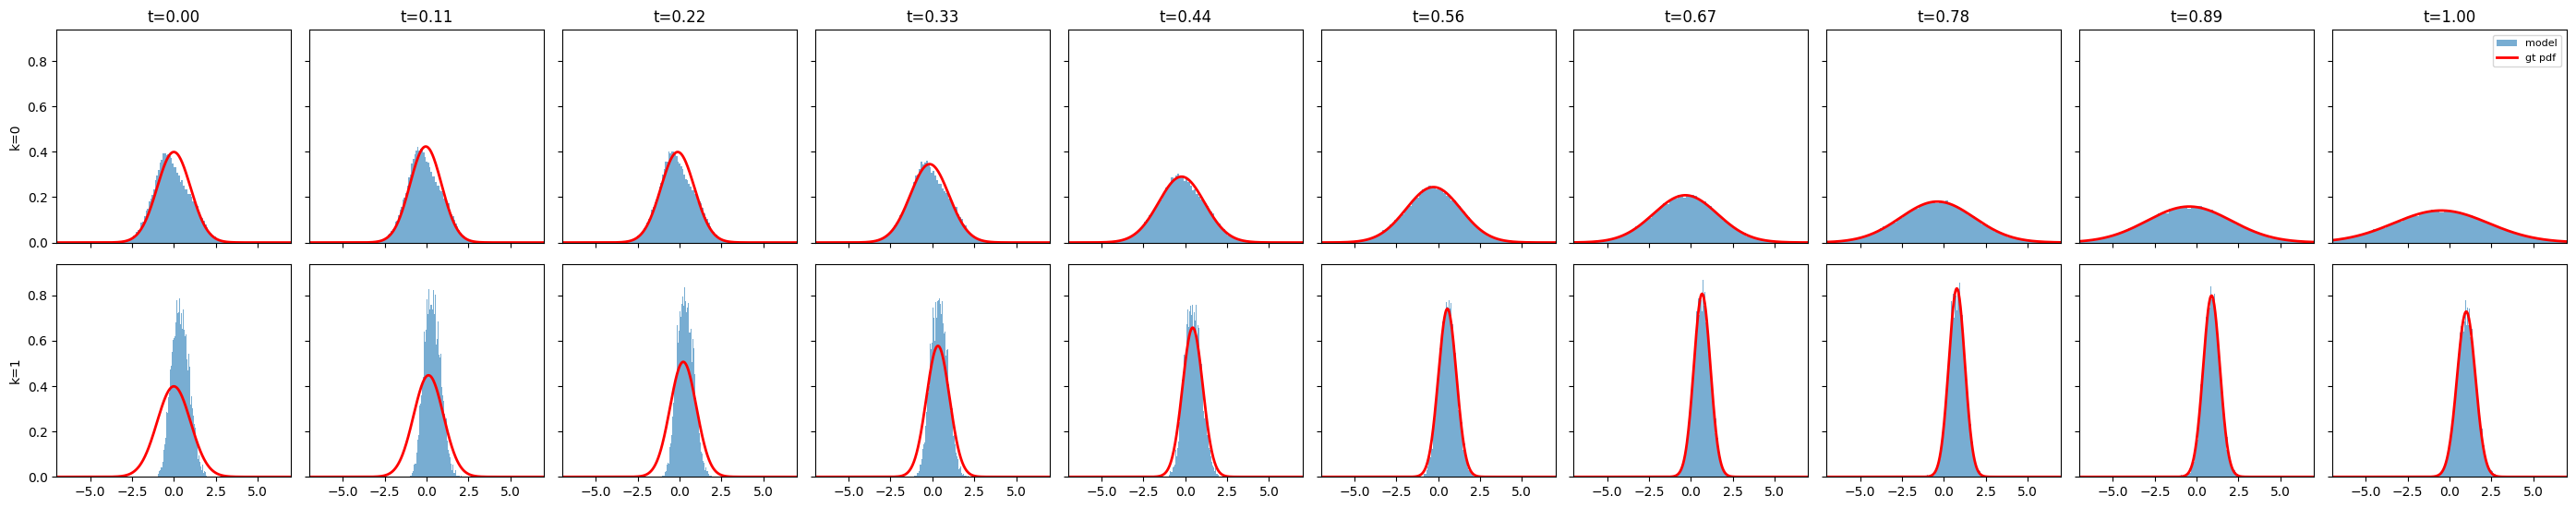

In [8]:
# Use the first continuous coordinate for 1D histograms (matching ground truth view).
traj = sol[:, :, 0].detach().cpu().numpy()
# Use labels predicted at final time step to partition samples at all time steps.
final_labels = sol[-1, :, n_continuous_features:].argmax(dim=-1).cpu().numpy()
T_np = T.detach().cpu().numpy()

x_min, x_max = -7, 7
x_grid = np.linspace(x_min, x_max, 500)

fig, axs = plt.subplots(
    n_discrete_values,
    len(T_np),
    figsize=(2.8 * len(T_np), 2.8 * n_discrete_values),
    sharex=True,
    sharey=True,
    squeeze=False,
 )

for k in range(n_discrete_values):
    mu_k = means[k, 0]
    var_k = variances[k, 0, 0]
    class_mask = final_labels == k

    for i, t_i in enumerate(T_np):
        vals_k_t = traj[i, class_mask]
        axs[k, i].hist(vals_k_t, bins=100, density=True, alpha=0.6, label="model")

        # Ground-truth conditional path: x_t = (1-t) x_0 + t x_1,
        # with x_0 ~ N(0,1), x_1|k ~ N(mu_k, var_k).
        mu_t = t_i * mu_k
        var_t = (1.0 - t_i) ** 2 + (t_i ** 2) * var_k
        std_t = np.sqrt(var_t)
        pdf_t = (1.0 / (np.sqrt(2.0 * np.pi) * std_t)) * np.exp(-0.5 * ((x_grid - mu_t) / std_t) ** 2)
        axs[k, i].plot(x_grid, pdf_t, "r-", linewidth=2.0, label="gt pdf")

        axs[k, i].set_xlim(x_min, x_max)
        if k == 0:
            axs[k, i].set_title(f"t={t_i:.2f}")
        if i == 0:
            axs[k, i].set_ylabel(f"k={k}")
        if k == 0 and i == len(T_np) - 1:
            axs[k, i].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

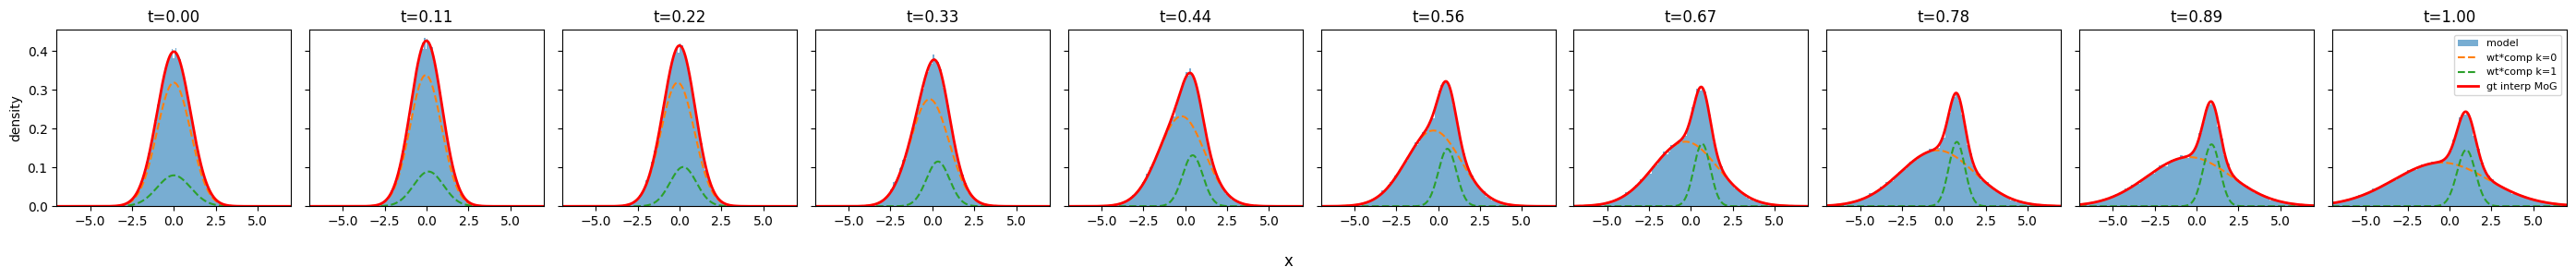

In [44]:
# Combined histogram over time vs ground-truth interpolated MoG density.
traj = sol[:, :, 0].detach().cpu().numpy() if torch.is_tensor(sol) else np.asarray(sol)[:, :, 0]
T_np = T.detach().cpu().numpy() if torch.is_tensor(T) else np.asarray(T)

x_min, x_max = -7, 7
x_grid = np.linspace(x_min, x_max, 1000)

fig, axs = plt.subplots(
    1, len(T_np),
    figsize=(2.8 * len(T_np), 3.0),
    sharex=True,
    sharey=True,
    squeeze=False,
 )
axs = axs[0]

for i, t_i in enumerate(T_np):
    samples_t = traj[i]
    axs[i].hist(samples_t, bins=120, density=True, alpha=0.6, label="model")

    # Ground-truth interpolation under affine path:
    # x_t = (1-t) x_0 + t x_1, x_0 ~ N(0,1), x_1 ~ MoG.
    mog_pdf_t = np.zeros_like(x_grid, dtype=np.float64)
    # Plot each component scaled by its prior weight
    for k in range(n_discrete_values):
        mu_k = means[k, 0]
        var_k = variances[k, 0, 0]
        mu_t = t_i * mu_k
        var_t = (1.0 - t_i) ** 2 + (t_i ** 2) * var_k
        std_t = np.sqrt(var_t)
        comp_pdf_t = (1.0 / (np.sqrt(2.0 * np.pi) * std_t)) * np.exp(-0.5 * ((x_grid - mu_t) / std_t) ** 2)
        weighted_comp = float(weights[k]) * comp_pdf_t
        axs[i].plot(x_grid, weighted_comp, '--', linewidth=1.5, label=f'wt*comp k={k}')
        mog_pdf_t += float(weights[k]) * comp_pdf_t

    # total interpolated MoG (sum of weighted components)
    axs[i].plot(x_grid, mog_pdf_t, 'r-', linewidth=2.0, label='gt interp MoG')

    axs[i].set_xlim(x_min, x_max)
    axs[i].set_title(f"t={t_i:.2f}")
    if i == 0:
        axs[i].set_ylabel("density")
    # only show legend on final subplot to reduce clutter
    if i == len(T_np) - 1:
        axs[i].legend(loc="upper right", fontsize=8)

fig.supxlabel("x")
plt.tight_layout()
plt.show()

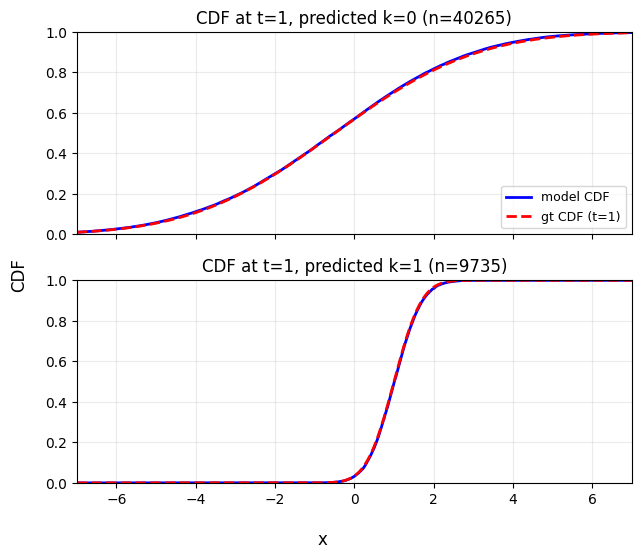

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- t=1 samples (continuous) and predicted discrete labels at t=1 ---
x_t1 = sol[-1, :, 0].detach().cpu().numpy()  # [B]
labels_t1 = sol[-1, :, n_continuous_features:].argmax(dim=-1).detach().cpu().numpy()  # [B]

x_min, x_max = -7, 7
x_grid = np.linspace(x_min, x_max, 800)

def normal_cdf_np(x: np.ndarray, mu: float, std: float) -> np.ndarray:
    z = (torch.from_numpy(x).float() - float(mu)) / float(std)
    return (0.5 * (1.0 + torch.erf(z / np.sqrt(2.0)))).numpy()

fig, axs = plt.subplots(
    n_discrete_values, 1,
    figsize=(6.5, 2.8 * n_discrete_values),
    sharex=True, sharey=True,
    squeeze=False,
)

for k in range(n_discrete_values):
    ax = axs[k, 0]
    mask = labels_t1 == k
    vals = x_t1[mask]

    # empirical CDF (model)
    s = np.sort(vals)
    emp_cdf = np.searchsorted(s, x_grid, side="right") / max(1, s.size)

    # ground-truth CDF at t=1: x_1 | k ~ N(mu_k, var_k)
    mu_k = float(means[k, 0])
    std_k = float(np.sqrt(variances[k, 0, 0]))
    gt_cdf = normal_cdf_np(x_grid.astype(np.float32), mu_k, std_k)

    ax.plot(x_grid, emp_cdf, "b-", lw=2.0, label="model CDF")
    ax.plot(x_grid, gt_cdf, "r--", lw=2.0, label="gt CDF (t=1)")
    ax.set_title(f"CDF at t=1, predicted k={k} (n={vals.size})")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)

axs[0, 0].legend(loc="lower right", fontsize=9)
fig.supxlabel("x")
fig.supylabel("CDF")
plt.tight_layout()
plt.show()

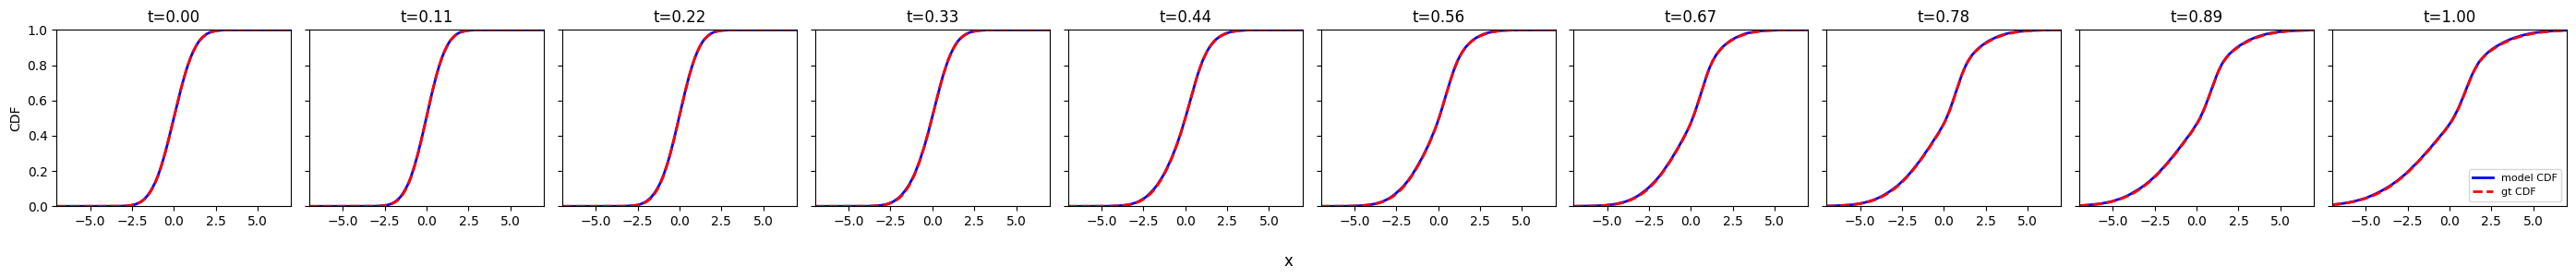

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Model samples for the 1D continuous coordinate at each time
traj = sol[:, :, 0].detach().cpu().numpy()  # [T, B]
T_np = T.detach().cpu().numpy()

x_min, x_max = -7, 7
x_grid = np.linspace(x_min, x_max, 800)

def normal_cdf_np(x: np.ndarray, mu: float, std: float) -> np.ndarray:
    # Phi((x-mu)/std) using torch.erf to avoid scipy dependency
    z = (torch.from_numpy(x).float() - float(mu)) / float(std)
    cdf = 0.5 * (1.0 + torch.erf(z / np.sqrt(2.0)))
    return cdf.numpy()

fig, axs = plt.subplots(
    1, len(T_np),
    figsize=(2.8 * len(T_np), 3.0),
    sharex=True, sharey=True, squeeze=False
)
axs = axs[0]

for i, t_i in enumerate(T_np):
    # ----- empirical CDF from model samples -----
    s = np.sort(traj[i])
    emp_cdf = np.searchsorted(s, x_grid, side="right") / s.size

    # ----- ground-truth CDF under affine path for x -----
    # x_t = (1-t) x0 + t x1, with x0~N(0,1), x1~MoG
    gt_cdf = np.zeros_like(x_grid, dtype=np.float64)
    for k in range(n_discrete_values):
        mu_k = float(means[k, 0])
        var_k = float(variances[k, 0, 0])
        mu_t = float(t_i) * mu_k
        var_t = (1.0 - float(t_i)) ** 2 + (float(t_i) ** 2) * var_k
        std_t = np.sqrt(var_t)
        gt_cdf += float(weights[k]) * normal_cdf_np(x_grid.astype(np.float32), mu_t, std_t)

    axs[i].plot(x_grid, emp_cdf, "b-", lw=2.0, label="model CDF")
    axs[i].plot(x_grid, gt_cdf, "r--", lw=2.0, label="gt CDF")
    axs[i].set_title(f"t={t_i:.2f}")
    axs[i].set_xlim(x_min, x_max)
    axs[i].set_ylim(0.0, 1.0)
    if i == 0:
        axs[i].set_ylabel("CDF")
    if i == len(T_np) - 1:
        axs[i].legend(loc="lower right", fontsize=8)

fig.supxlabel("x")
plt.tight_layout()
plt.show()

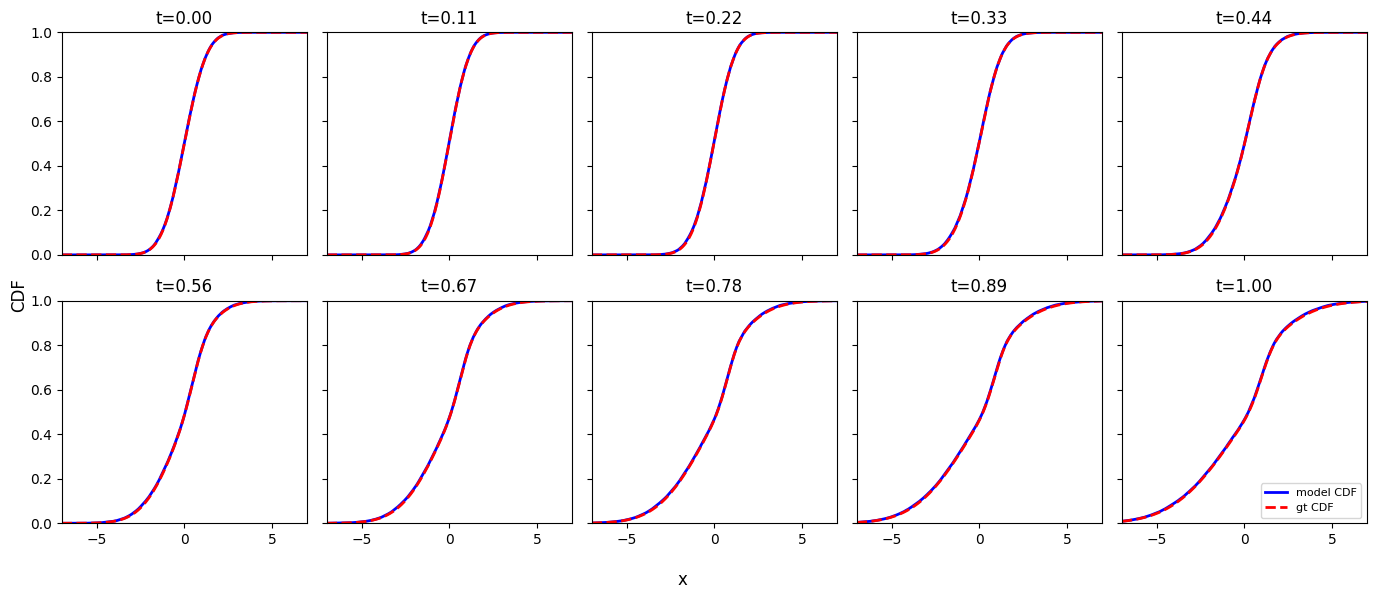

In [ ]:
# ...existing code...

n_times = len(T_np)
ncols = 5
nrows = 2  # requested 5 by 2

fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(2.8 * ncols, 3.0 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axs_flat = axs.ravel()

for i, t_i in enumerate(T_np):
    ax = axs_flat[i]

    # ----- empirical CDF from model samples -----
    s = np.sort(traj[i])
    emp_cdf = np.searchsorted(s, x_grid, side="right") / s.size

    # ----- ground-truth CDF under affine path for x -----
    gt_cdf = np.zeros_like(x_grid, dtype=np.float64)
    for k in range(n_discrete_values):
        mu_k = float(means[k, 0])
        var_k = float(variances[k, 0, 0])
        mu_t = float(t_i) * mu_k
        var_t = (1.0 - float(t_i)) ** 2 + (float(t_i) ** 2) * var_k
        std_t = np.sqrt(var_t)
        gt_cdf += float(weights[k]) * normal_cdf_np(x_grid.astype(np.float32), mu_t, std_t)

    ax.plot(x_grid, emp_cdf, "b-", lw=2.0, label="model CDF")
    ax.plot(x_grid, gt_cdf, "r--", lw=2.0, label="gt CDF")
    ax.set_title(f"t={t_i:.2f}")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, 1.0)

# Hide any unused axes (in case n_times != 10)
for j in range(n_times, nrows * ncols):
    axs_flat[j].axis("off")

# Put legend on the last *used* axis
axs_flat[n_times - 1].legend(loc="lower right", fontsize=8)

fig.supxlabel("x")
fig.supylabel("CDF")
plt.tight_layout()
plt.show()

# ...existing code...

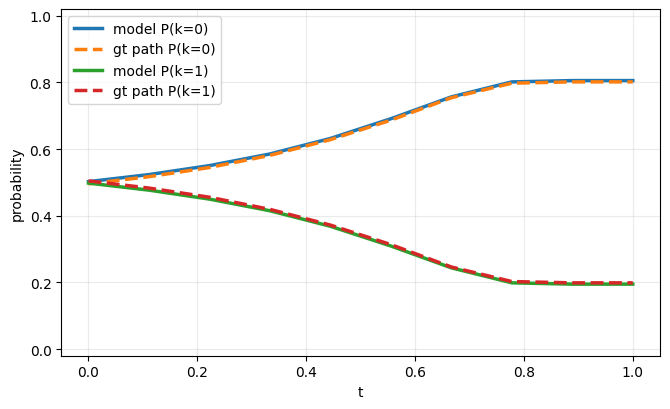

In [13]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ----- time grid -----
T_np = T.detach().cpu().numpy()

# ----- model: empirical P(k | t) from discrete coords in sol -----
disc_start = n_continuous_features
disc_end = n_continuous_features + n_discrete_values

disc_model = sol[:, :, disc_start:disc_end].detach().cpu().numpy()          # [T, B, K]
labels_model = disc_model.argmax(axis=-1)                                   # [T, B]
p_model = np.stack([(labels_model == k).mean(axis=1) for k in range(n_discrete_values)], axis=1)  # [T, K]

# ----- ground truth: empirical P(k | t) along affine probability path -----
B_gt = int(1e5)  # match model batch size (e.g., 50k)

# sample labels from mixture and build one-hot "discrete state" at t=1
_, gt_labels = gmm.sample(n_samples=B_gt)                                   # [B_gt]
y1 = np.eye(n_discrete_values, dtype=np.float32)[gt_labels]                 # [B_gt, K]

# discrete part of x0 is standard normal (matches how you trained: x0 = randn_like(x1))
y0 = np.random.randn(B_gt, n_discrete_values).astype(np.float32)            # [B_gt, K]

# affine path for discrete coords: y_t = (1-t) y0 + t y1
t = T_np[:, None, None].astype(np.float32)                                  # [T, 1, 1]
y_t = (1.0 - t) * y0[None, :, :] + t * y1[None, :, :]                       # [T, B_gt, K]
labels_gt = y_t.argmax(axis=-1)                                              # [T, B_gt]
p_gt = np.stack([(labels_gt == k).mean(axis=1) for k in range(n_discrete_values)], axis=1)  # [T, K]

# ----- plot -----
plt.figure(figsize=(6.8, 4.2))
for k in range(n_discrete_values):
    plt.plot(T_np, p_model[:, k], lw=2.5, label=f"model P(k={k})")
    plt.plot(T_np, p_gt[:, k], "--", lw=2.5, label=f"gt path P(k={k})")

plt.xlabel("t")
plt.ylabel("probability")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

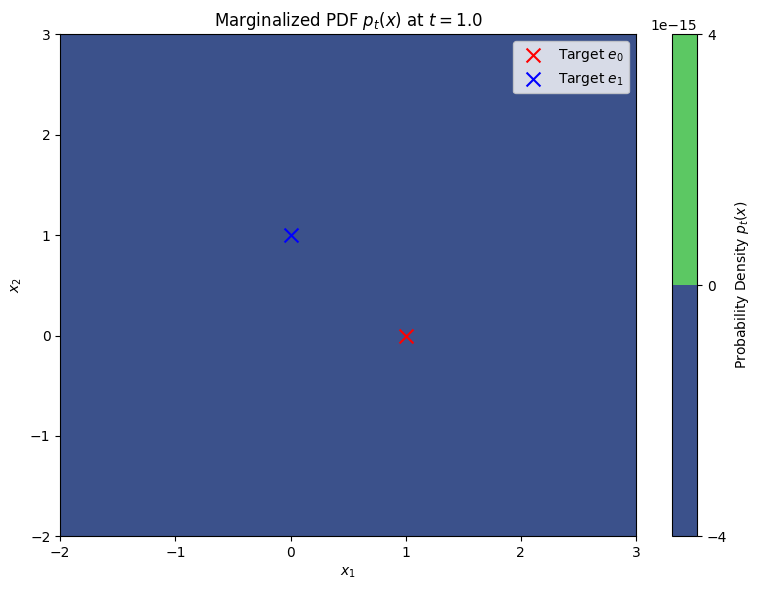

In [14]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def marginalized_pdf(x_grid, t, p, e0, e1):
    """
    Computes the exact marginalized PDF p_t(x) over a 2D grid.
    
    Args:
        x_grid (torch.Tensor): 2D grid of points, shape (N, N, 2).
        t (float): Current timestep.
        p (float): Prior probability of e1.
        e0, e1 (torch.Tensor): The one-hot encoded ground truth states.
        
    Returns:
        torch.Tensor: The probability density at each point in the grid.
    """
    sigma_t = max(1.0 - t, 1e-5) # Prevent division by zero at t=1
    
    # The means for each class at time t
    mu_0 = t * e0
    mu_1 = t * e1
    
    # Calculate the isotropic Gaussian PDF for class 0
    dist_sq_0 = torch.sum((x_grid - mu_0) ** 2, dim=-1)
    pdf_0 = torch.exp(-dist_sq_0 / (2 * sigma_t ** 2)) / (2 * np.pi * sigma_t ** 2)
    
    # Calculate the isotropic Gaussian PDF for class 1
    dist_sq_1 = torch.sum((x_grid - mu_1) ** 2, dim=-1)
    pdf_1 = torch.exp(-dist_sq_1 / (2 * sigma_t ** 2)) / (2 * np.pi * sigma_t ** 2)
    
    # The marginalized PDF is the mixture of the two
    return (1 - p) * pdf_0 + p * pdf_1

# --- Plotting the Marginalized PDF ---
device = torch.device("cpu")
e0 = torch.tensor([1.0, 0.0])
e1 = torch.tensor([0.0, 1.0])
prior_p = 0.3

# Create a 2D grid over our space
grid_res = 100
x_coords = torch.linspace(-2, 3, grid_res)
y_coords = torch.linspace(-2, 3, grid_res)
X, Y = torch.meshgrid(x_coords, y_coords, indexing='xy')
x_grid = torch.stack([X, Y], dim=-1)

# Choose a specific timestep to visualize the PDF
t_val = 1.0 

# Compute the marginalized density
density = marginalized_pdf(x_grid, t_val, prior_p, e0, e1)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(X.numpy(), Y.numpy(), density.numpy(), levels=50, cmap='viridis')
plt.colorbar(label='Probability Density $p_t(x)$')
plt.scatter([e0[0].item()], [e0[1].item()], color='red', marker='x', s=100, label='Target $e_0$')
plt.scatter([e1[0].item()], [e1[1].item()], color='blue', marker='x', s=100, label='Target $e_1$')
plt.title(f'Marginalized PDF $p_t(x)$ at $t = {t_val}$')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.tight_layout()
plt.show()

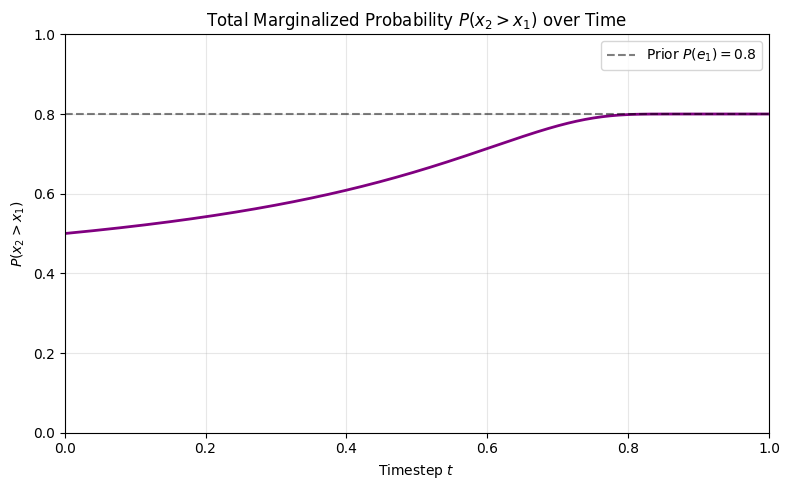

In [15]:
import torch
import matplotlib.pyplot as plt

def prob_x2_greater_than_x1(t, p):
    """
    Analytically computes P(x_2 > x_1) for the marginalized Gaussian mixture.
    
    Args:
        t (torch.Tensor): Timesteps from 0 to 1.
        p (float): Prior probability of class 1 (e_1).
        
    Returns:
        torch.Tensor: The probability P(x_2 > x_1) at each timestep.
    """
    sigma_t = torch.clamp(1.0 - t, min=1e-5)
    
    # Standard deviation of the difference Z = x_2 - x_1
    sigma_z = torch.sqrt(torch.tensor(2.0)) * sigma_t
    
    # Standard normal distribution to compute the CDF (\Phi)
    normal = torch.distributions.Normal(0, 1)
    
    # P(Z > 0 | e_0)
    # Z ~ N(-t, sigma_z^2), so we want P(Z > 0)
    prob_given_e0 = normal.cdf(-t / sigma_z)
    
    # P(Z > 0 | e_1)
    # Z ~ N(t, sigma_z^2), so we want P(Z > 0)
    prob_given_e1 = normal.cdf(t / sigma_z)
    
    # Marginalize over the prior
    return (1 - p) * prob_given_e0 + p * prob_given_e1

# --- Plotting ---
t_steps = torch.linspace(0, 0.999, 500)
prior_p = 0.8  # Let's say class 1 is highly likely

probs = prob_x2_greater_than_x1(t_steps, prior_p)

plt.figure(figsize=(8, 5))
plt.plot(t_steps.numpy(), probs.numpy(), color='purple', linewidth=2)
plt.axhline(prior_p, color='black', linestyle='--', alpha=0.5, label=f'Prior $P(e_1) = {prior_p}$')
plt.title('Total Marginalized Probability $P(x_2 > x_1)$ over Time')
plt.xlabel('Timestep $t$')
plt.ylabel('$P(x_2 > x_1)$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

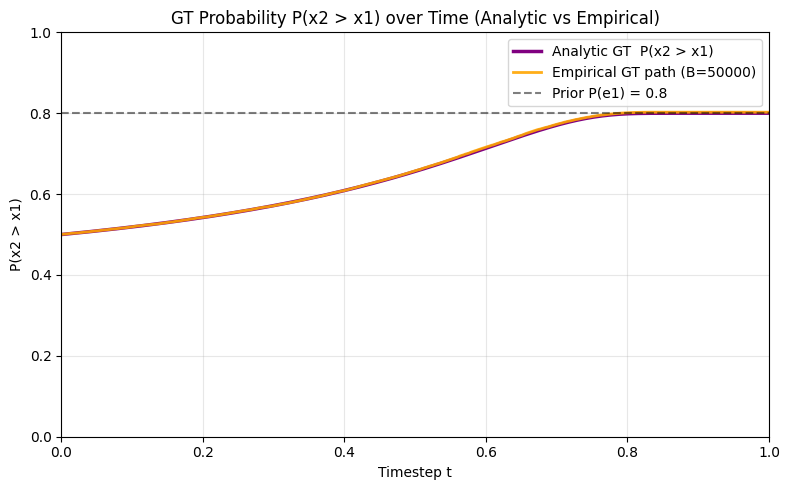

In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def prob_x2_greater_than_x1(t, p):
    """
    Analytically computes P(x_2 > x_1) for the marginalized Gaussian mixture.

    Here x_t = t * e + (1 - t) * z,  z ~ N(0, I),  e in {e0=[1,0], e1=[0,1]} with P(e1)=p.
    """
    sigma_t = torch.clamp(1.0 - t, min=1e-5)

    # Standard deviation of the difference Z = x_2 - x_1
    sigma_z = torch.sqrt(torch.tensor(2.0, device=t.device, dtype=t.dtype)) * sigma_t

    normal = torch.distributions.Normal(
        torch.tensor(0.0, device=t.device, dtype=t.dtype),
        torch.tensor(1.0, device=t.device, dtype=t.dtype),
    )

    # P(Z > 0 | e_0): Z ~ N(-t, sigma_z^2)
    prob_given_e0 = normal.cdf(-t / sigma_z)

    # P(Z > 0 | e_1): Z ~ N(t, sigma_z^2)
    prob_given_e1 = normal.cdf(t / sigma_z)

    return (1 - p) * prob_given_e0 + p * prob_given_e1

# --- Plotting (analytic vs empirical GT path sampling) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

t_steps = torch.linspace(0, 0.999, 500, device=device)
prior_p = 0.8

# Analytic curve
probs_analytic = prob_x2_greater_than_x1(t_steps, prior_p)

# Empirical sampling from the GT probability path: x_t = (1-t) z + t e
B = 50_000  # increase for smoother empirical curve
labels = torch.bernoulli(torch.full((B,), float(prior_p), device=device)).long()  # 1 with prob p
e = F.one_hot(labels, num_classes=2).float()  # class0->[1,0], class1->[0,1]
z = torch.randn(B, 2, device=device)

probs_emp = torch.empty(t_steps.shape[0], device=device)
for i, t in enumerate(t_steps):
    xt = (1.0 - t) * z + t * e
    probs_emp[i] = (xt[:, 1] > xt[:, 0]).float().mean()

# Move to CPU for matplotlib
t_cpu = t_steps.detach().cpu().numpy()
ana_cpu = probs_analytic.detach().cpu().numpy()
emp_cpu = probs_emp.detach().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_cpu, ana_cpu, color="purple", linewidth=2.5, label="Analytic GT  P(x2 > x1)")
plt.plot(t_cpu, emp_cpu, color="orange", linewidth=2.0, alpha=0.9, label=f"Empirical GT path (B={B})")
plt.axhline(prior_p, color="black", linestyle="--", alpha=0.5, label=f"Prior P(e1) = {prior_p}")

plt.title("GT Probability P(x2 > x1) over Time (Analytic vs Empirical)")
plt.xlabel("Timestep t")
plt.ylabel("P(x2 > x1)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

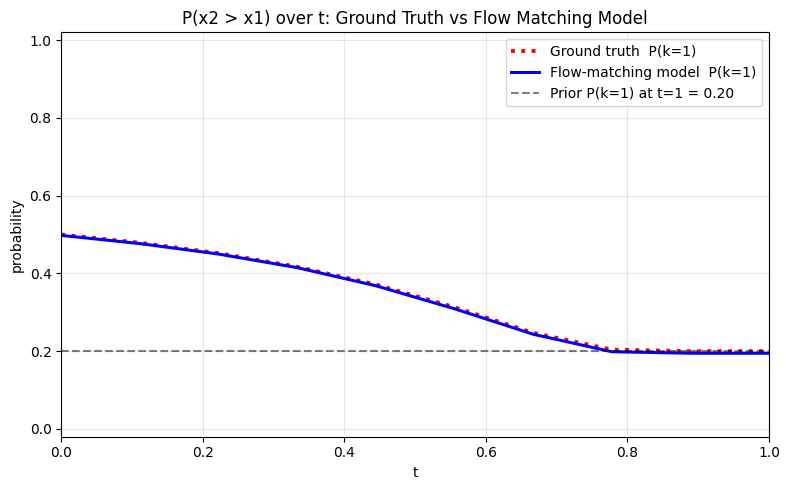

In [ ]:
import torch
import matplotlib.pyplot as plt

# Uses the analytic function you already defined above:
# def prob_x2_greater_than_x1(t, p): ...

# ----- choose prior -----
prior_p = float(weights[1])  # P(e1)

# ----- time grid (use the same grid as the solver output) -----
t_grid = T.detach()
t_cpu = t_grid.detach().cpu().numpy()

def prob_x2_greater_than_x1(t, p):
    """
    Analytically computes P(x_2 > x_1) for the marginalized Gaussian mixture.

    Here x_t = t * e + (1 - t) * z,  z ~ N(0, I),  e in {e0=[1,0], e1=[0,1]} with P(e1)=p.
    """
    sigma_t = torch.clamp(1.0 - t, min=1e-5)

    # Standard deviation of the difference Z = x_2 - x_1
    sigma_z = torch.sqrt(torch.tensor(2.0, device=t.device, dtype=t.dtype)) * sigma_t

    normal = torch.distributions.Normal(
        torch.tensor(0.0, device=t.device, dtype=t.dtype),
        torch.tensor(1.0, device=t.device, dtype=t.dtype),
    )

    # P(Z > 0 | e_0): Z ~ N(-t, sigma_z^2)
    prob_given_e0 = normal.cdf(-t / sigma_z)

    # P(Z > 0 | e_1): Z ~ N(t, sigma_z^2)
    prob_given_e1 = normal.cdf(t / sigma_z)

    return (1 - p) * prob_given_e0 + p * prob_given_e1

# ----- theoretical GT curve -----
gt_probs = prob_x2_greater_than_x1(t_grid, prior_p).detach().cpu().numpy()

# ----- model-derived probabilities from solver samples -----
disc_start = n_continuous_features
disc_end = n_continuous_features + 2  # Bernoulli -> 2 dims

y_model = sol[:, :, disc_start:disc_end].detach()  # [T, B, 2]
model_probs = (y_model[:, :, 1] > y_model[:, :, 0]).float().mean(dim=1).cpu().numpy()  # [T]

# ----- plot -----
plt.figure(figsize=(8, 5))
plt.plot(t_cpu, gt_probs, 'r:', lw=2.8, label='Ground truth  P(k=1)')
plt.plot(t_cpu, model_probs, '-', color='blue', lw=2.2, label='Flow-matching model  P(k=1)')
plt.axhline(prior_p, color='black', ls='--', alpha=0.5, label='Prior P(k=1) at t=1 = {prior_p:.2f}')

plt.title('P(x2 > x1) over t: Ground Truth vs Flow Matching Model')
plt.xlabel('t')
plt.ylabel('probability')
plt.xlim(float(t_cpu.min()), float(t_cpu.max()))
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

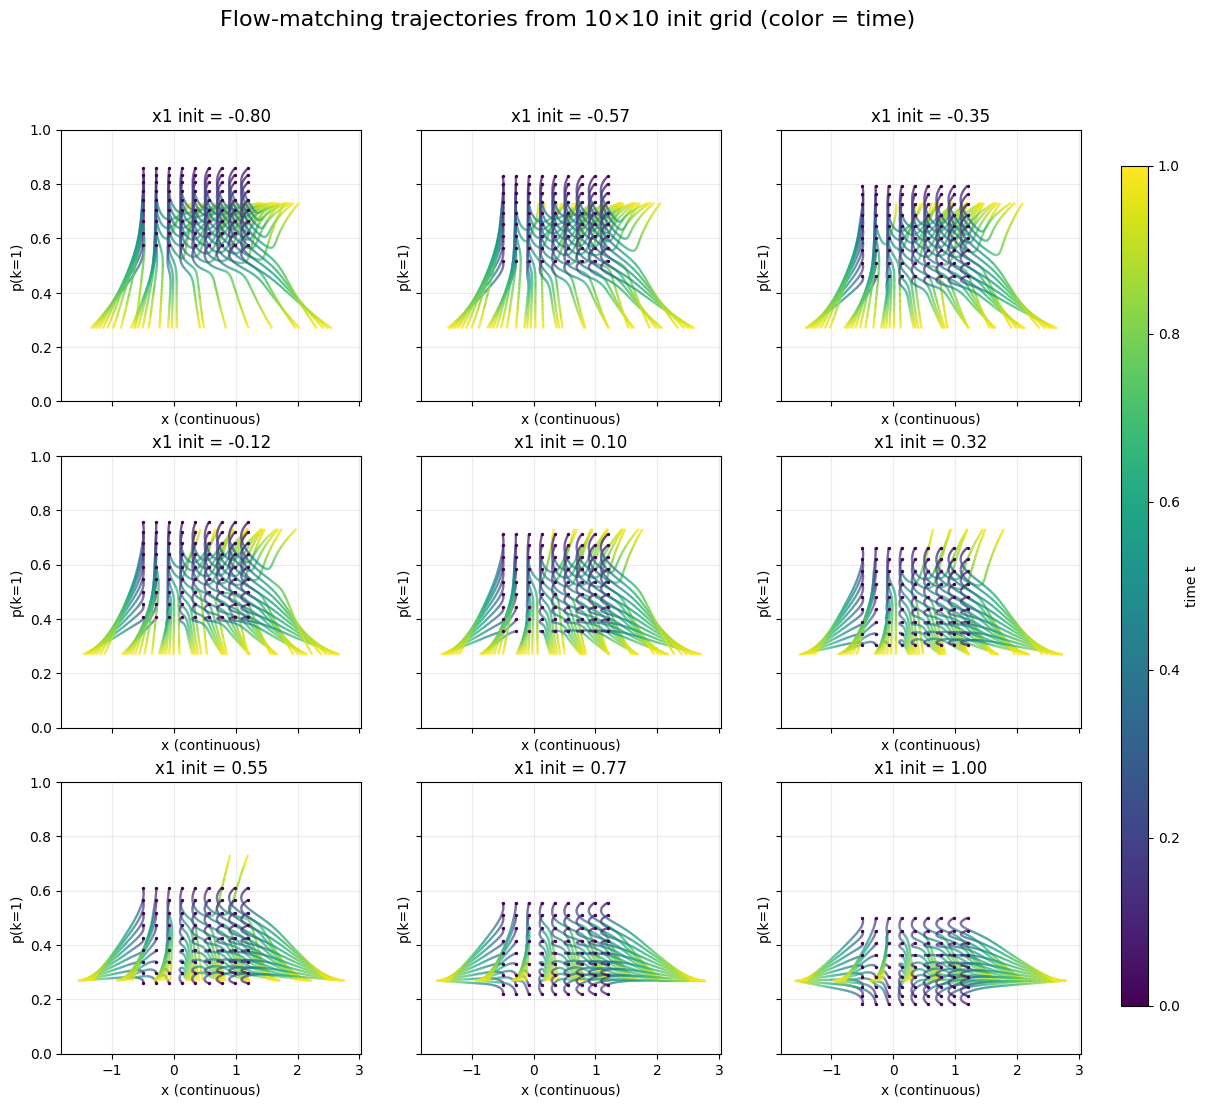

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# Trajectories in the (x_continuous, p(k=1)) plane evolved under the flow-matching sampler.
# x-axis: continuous coordinate x(t)
# y-axis: p(k=1) computed from the 2 "discrete" logits via softmax

assert int(n_discrete_values) == 2, "This visualization assumes 2 discrete coordinates (x1, x2)."

# ----- 10x10 grid of starting points -----
x_levels = np.linspace(-0.5, 1.2, num=9, dtype=np.float32)   # continuous x0 range (unchanged)
x1_levels = np.linspace(-.8, 1.0, num=9, dtype=np.float32)  # sweep x1 init across subplots
x2_levels = np.linspace(-0.5, 1.0, num=9, dtype=np.float32)  # sweep x2 init within each subplot

X2_0, X_0 = np.meshgrid(x2_levels, x_levels)  # shapes (10,10)
x0 = X_0.reshape(-1)  # (100,)

# Prepare 5x2 plot
n_plots = 9
ncols = 3
nrows = 3
fig, axs = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows), sharex=True, sharey=True)
axs = axs.ravel()

for plot_idx, x1_init_val in enumerate(x1_levels[:n_plots]):
    x2_0 = X2_0.reshape(-1)  # (100,)
    x1_0 = np.full_like(x0, x1_init_val, dtype=np.float32)  # (100,)

    # State format: [continuous, x1, x2]
    x_init_grid = np.stack([x0, x1_0, x2_0], axis=1)  # (100, 3)
    x_init_grid = torch.tensor(x_init_grid, dtype=torch.float32, device=device)

    # ----- flow-matching sampler (ODE solver), like earlier -----
    time_grid = torch.linspace(0.0, 1.0, 200, device=device)
    step_size_vis = 0.01
    solver_vis = ODESolver(velocity_model=wrapped_vf)
    sol_vis = solver_vis.sample(
        time_grid=time_grid,
        x_init=x_init_grid,
        method="midpoint",
        step_size=step_size_vis,
        return_intermediates=True,
    )  # expected shape [T, 100, 3]

    # Extract coordinates for plotting
    x_cont_t = sol_vis[:, :, 0]  # [T, 100]
    x1_t = sol_vis[:, :, 1]      # [T, 100]
    x2_t = sol_vis[:, :, 2]      # [T, 100]

    # p(k=1) from logits [x1, x2]
    p1_t = torch.stack([x1_t, x2_t], dim=-1)              # [T, 100, 2]
    p1_t = torch.softmax(p1_t, dim=-1)[..., 1]            # [T, 100]

    t_cpu = time_grid.detach().cpu().numpy()
    x_cont_cpu = x_cont_t.detach().cpu().numpy()
    p1_cpu = p1_t.detach().cpu().numpy()

    ax = axs[plot_idx]
    norm = Normalize(vmin=float(t_cpu.min()), vmax=float(t_cpu.max()))
    cmap = plt.cm.viridis

    for idx in range(p1_cpu.shape[1]):
        pts = np.column_stack([x_cont_cpu[:, idx], p1_cpu[:, idx]])  # (T, 2)
        segments = np.stack([pts[:-1], pts[1:]], axis=1)              # (T-1, 2, 2)
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(t_cpu[:-1])
        lc.set_linewidth(1.6)
        ax.add_collection(lc)
        ax.scatter([pts[0, 0]], [pts[0, 1]], s=2, color=cmap(norm(t_cpu[0])), zorder=3)

    # Axis limits
    x_min = float(np.min(x_cont_cpu))
    x_max = float(np.max(x_cont_cpu))
    x_pad = 0.05 * (x_max - x_min + 1e-6)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(0.0, 1.0)

    ax.set_xlabel("x (continuous)")
    ax.set_ylabel("p(k=1)")
    ax.set_title(f"x1 init = {x1_init_val:.2f}")
    ax.grid(alpha=0.25)

# Hide any unused axes (if n_plots < nrows*ncols)
for j in range(n_plots, nrows * ncols):
    axs[j].axis("off")

# Shared colorbar for time (on the right of the figure)
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label="time t")

plt.suptitle("Flow-matching trajectories from 10×10 init grid (color = time)", fontsize=16)
plt.show()

Text(0, 0.5, 'p(1)')

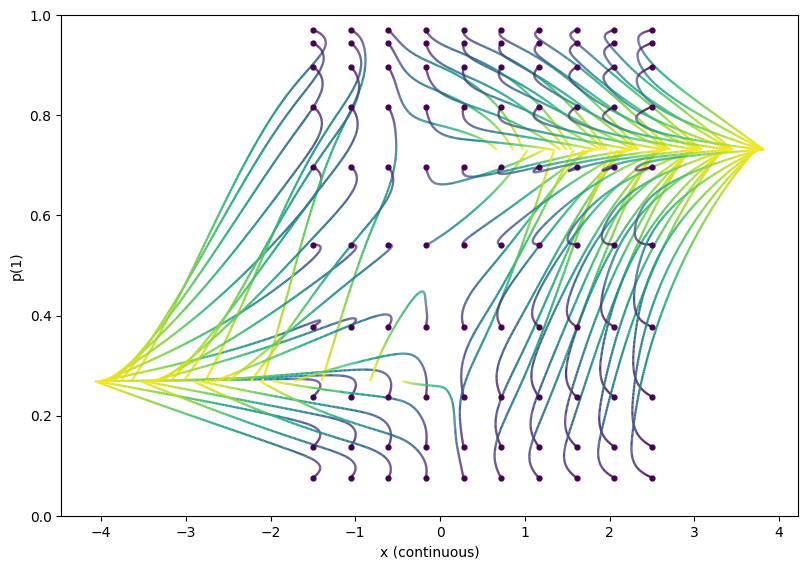

In [ ]:
# ...existing code...
# Extract coordinates for plotting
x_cont_t = sol_vis[:, :, 0]  # [T, 100]
x1_t = sol_vis[:, :, 1]      # [T, 100]
x2_t = sol_vis[:, :, 2]      # [T, 100]

# Option A (recommended): p(1) = softmax([x1, x2])_1
p1_t = torch.softmax(torch.stack([x1_t, x2_t], dim=-1), dim=-1)[..., 1]  # [T, 100]

# Option B (equivalent for K=2): p(1) = sigmoid(x2 - x1)
# p1_t = torch.sigmoid(x2_t - x1_t)

t_cpu = time_grid.detach().cpu().numpy()
x_cont_cpu = x_cont_t.detach().cpu().numpy()
p1_cpu = p1_t.detach().cpu().numpy()

# ----- single plot with time-colored curves -----
fig, ax = plt.subplots(1, 1, figsize=(9.5, 6.5))
norm = Normalize(vmin=float(t_cpu.min()), vmax=float(t_cpu.max()))
cmap = plt.cm.viridis

for idx in range(p1_cpu.shape[1]):
    pts = np.column_stack([x_cont_cpu[:, idx], p1_cpu[:, idx]])  # (T, 2)
    segments = np.stack([pts[:-1], pts[1:]], axis=1)             # (T-1, 2, 2)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(t_cpu[:-1])
    lc.set_linewidth(1.6)
    ax.add_collection(lc)

    ax.scatter([pts[0, 0]], [pts[0, 1]], s=12, color=cmap(norm(t_cpu[0])), zorder=3)

ax.set_ylim(0.0, 1.0)
ax.set_xlabel("x (continuous)")
ax.set_ylabel("p(1)")
# ...existing code...

In [ ]:
# Plot weighted component PDFs for the last timestep only
import numpy as np
import matplotlib.pyplot as plt

# get last time and samples (assumes T and traj are defined earlier)
T_np = T.detach().cpu().numpy() if torch.is_tensor(T) else np.asarray(T)
last_idx = -1
t_last = float(T_np[last_idx])
samples_last = traj[last_idx]  # traj = sol[:, :, 0] defined earlier

x_min, x_max = -7, 7
x_grid = np.linspace(x_min, x_max, 1000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(samples_last, bins=120, density=True, alpha=0.6, label='model (last t)')

mog_pdf = np.zeros_like(x_grid, dtype=np.float64)
for k in range(n_discrete_values):
    mu_k = means[k, 0]
    var_k = variances[k, 0, 0]
    mu_t = t_last * mu_k
    var_t = (1.0 - t_last) ** 2 + (t_last ** 2) * var_k
    std_t = np.sqrt(var_t)
    comp_pdf = (1.0 / (np.sqrt(2.0 * np.pi) * std_t)) * np.exp(-0.5 * ((x_grid - mu_t) / std_t) ** 2)
    weighted_comp = float(weights[k]) * comp_pdf
    ax.plot(x_grid, weighted_comp, '--', linewidth=1.5, label=f'prior*comp k={k}')
    mog_pdf += weighted_comp

# total interpolated MoG (weighted sum)
ax.plot(x_grid, mog_pdf, 'r-', linewidth=2.0, label='gt interp MoG')

ax.set_xlim(x_min, x_max)
ax.set_ylabel('density')
ax.set_title(f'Component-weighted PDFs at last t = {t_last:.3f}')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

<module 'torch.nn.functional' from '/home/nagleam/miniforge3/envs/flow-matching/lib/python3.14/site-packages/torch/nn/functional.py'>

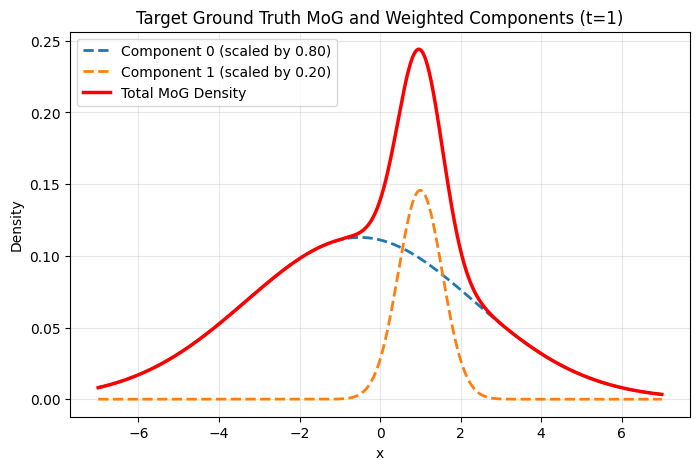

In [47]:
# Plot weighted ground truth component PDFs at t=1
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = -7, 7
x_grid = np.linspace(x_min, x_max, 1000)

fig, ax = plt.subplots(figsize=(8, 5))

total_pdf = np.zeros_like(x_grid)

for k in range(n_discrete_values):
    mu_k = means[k, 0]
    std_k = np.sqrt(variances[k, 0, 0])
    prior_k = weights[k]
    
    # Univariate Gaussian PDF
    comp_pdf = (1.0 / (std_k * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - mu_k) / std_k) ** 2)
    weighted_pdf = prior_k * comp_pdf
    
    ax.plot(x_grid, weighted_pdf, '--', lw=2, label=f'Component {k} (scaled by {prior_k:.2f})')
    total_pdf += weighted_pdf

ax.plot(x_grid, total_pdf, 'r-', lw=2.5, label='Total MoG Density')
ax.set_title("Target Ground Truth MoG and Weighted Components (t=1)")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
plt.show()